# Investigating Gaussianity of the constructed data terms

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import receiver_simulation
import noise_wave_gcr

Generate 10,000 samples with Gaussian noise in $P_{\rm src}, P_{\rm L}, P_{\rm NS}, T_{\rm }

In [48]:
n_samp = int(1e6)

T_l = 273+20 # K
T_ns = 273+1000 # K
T_src = 273+20 # K

t_int = 60 # seconds
delta_nu = 100e3 # Hz

gain = 10e6

# Gammas
gamma_src = 0.9j
gamma_rec = 0.02+0.01j

gamma_l = 0
gamma_ns = 0

# Receiver Noise Terms
T_unc = 300
T_0 = 300
T_sin = 20
T_cos = -20

# Temperature Sensor
temp_sens_variance = 0.1**2

p_src = receiver_simulation.compute_radiometer_power(T_src,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_src, gain, add_noise=False)

p_l = receiver_simulation.compute_radiometer_power(T_l,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_l, gain, add_noise=False)

p_ns = receiver_simulation.compute_radiometer_power(T_ns,T_unc, T_sin, T_cos, T_0,
                                                     gamma_rec, gamma_ns, gain, add_noise=False)


d_true = noise_wave_gcr.construct_new_data_i(p_src, p_l, p_ns, T_src, T_l, T_ns, gamma_rec, gamma_src)


In [49]:
p_src_var = (p_src**2) / (delta_nu*t_int)
p_l_var = (p_l**2) / (delta_nu*t_int) 
p_ns_var = (p_ns**2) / (delta_nu*t_int)


p_src_meas = np.abs(np.random.normal(loc=p_src,scale=np.sqrt(p_src_var), size=n_samp))
p_l_meas = np.abs(np.random.normal(loc=p_l,scale=np.sqrt(p_l_var), size=n_samp))
p_ns_meas = np.abs(np.random.normal(loc=p_ns,scale=np.sqrt(p_src_var), size=n_samp))

T_src_meas = np.abs(np.random.normal(loc=T_src,scale=np.sqrt(temp_sens_variance), size=n_samp))
T_l_meas = np.abs(np.random.normal(loc=T_l,scale=np.sqrt(temp_sens_variance) , size=n_samp))
T_ns_meas = np.abs(np.random.normal(loc=T_ns,scale=np.sqrt(temp_sens_variance), size=n_samp))



d_meas = noise_wave_gcr.construct_new_data_i(p_src_meas,
                                              p_l_meas,
                                              p_ns_meas,
                                              T_src_meas,
                                              T_l_meas,
                                              T_ns_meas,
                                              gamma_rec,
                                              gamma_src)




dd_dp_src_sqr 1.0000000000000002e-14
dd_dp_ns_sqr 3.536232892434735e-18
dd_dp_l_sqr 9.627438751250524e-15
dd_dt_src_sqr 0.03477216670488561
dd_dt_ns_sqr 0.0003532697543600524
dd_dt_l_sqr 0.9617813719358961

var_p_src 6227579276437.058
var_p_ns 41205449602204.18
var_p_l 5857921207704.168


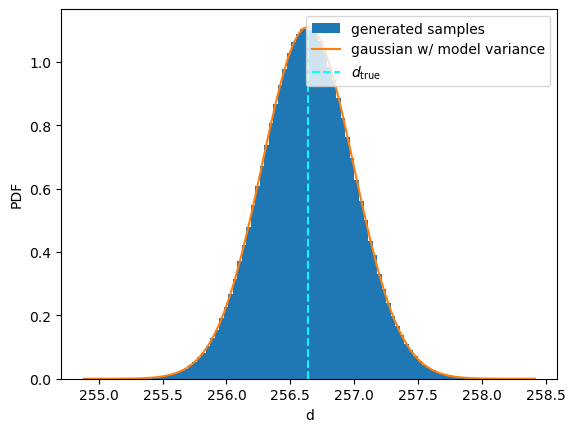

In [50]:
def gaussian(x, mu, sig):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

expected_variance = noise_wave_gcr.quadrature_data_variance_new(p_src, p_l, p_ns, T_src, T_l, T_ns, gamma_rec, gamma_src, t_int, delta_nu,
                                                                 temp_sens_variance)


x_axis = np.linspace(np.min(d_meas), np.max(d_meas), 100)
y_max = np.max(gaussian(x_axis, d_true, sig=np.sqrt(expected_variance)))

plt.hist(d_meas, 100, density=True, label='generated samples')
plt.plot(x_axis, gaussian(x_axis, d_true, sig=np.sqrt(expected_variance)), label='gaussian w/ model variance')
plt.vlines(x=d_true, ymin=0, ymax=y_max, colors='cyan', linestyles='--', label=r"$d_{\rm true}$")
plt.ylabel('PDF')
plt.xlabel('d')
plt.legend()
plt.show()



In [51]:
print('sample median: ', np.median(d_meas))
print('sample mean: ', np.mean(d_meas))
print('d_true', d_true)

print('Sample Variance', np.var(d_meas))
print('Expected Variance: ',expected_variance)

print(expected_variance / np.var(d_meas))

sample median:  256.6365169008576
sample mean:  256.6366653444712
d_true 256.63648344437445
Sample Variance 0.128832898068609
Expected Variance:  0.12878735055137625
0.9996464605088018
